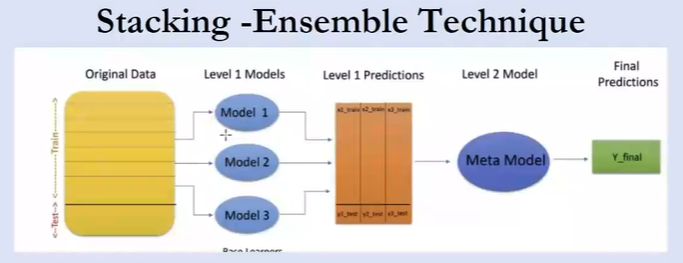

## What is Stacking?

* Stacking combines **multiple diverse models** (called base learners) and trains a **meta-model** to combine their outputs.
* Unlike Bagging/Boosting, models in stacking can be **completely different** (e.g., Decision Tree, SVM, KNN).
* Final prediction comes from a meta-model trained on predictions of base learners.

### How It Works:

1. **Train Base Models (Level-0)**
* These are individual models trained on the original data.
* Each model makes predictions.

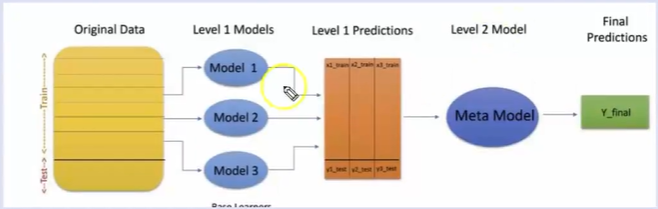

2. **Train Meta-Model (Level-1)**

* Take predictions of base models as input features.
* Train a new model (e.g., Logistic Regression) on these predictions.
* Meta-model learns how to best combine the base models' outputs.

## Step-by-step Example:

Dataset (simplified):

| ID | Age | BP | Outcome ($y$) |
| --- | --- | --- | --- |
| 1 | 45 | 130 | 1 |
| 2 | 36 | 120 | 0 |
| 3 | 50 | 140 | 1 |
| 4 | 29 | 110 | 0 |

Let's say we use 3 base models:

1. Decision Tree
2. K-Nearest Neighbors
3. Logistic Regression

We train these on the original features (Age, BP), and each model gives its own prediction.

### Base Model Predictions (Level-0 outputs):

| ID | DT_Pred | KNN_Pred | LR_Pred | True y |
| --- | --- | --- | --- | --- |
| 1 | 1 | 1 | 1 | 1 |
| 2 | 0 | 0 | 1 | 0 |
| 3 | 1 | 1 | 1 | 1 |
| 4 | 0 | 0 | 0 | 0 |

Now, instead of using Age and BP again, the meta-model uses these 3 predictions (`DT_Pred`, `KNN_Pred`, `LR_Pred`) as new features:

## Meta-Model Training:

New training data for meta-model becomes:

| DT_Pred | KNN_Pred | LR_Pred | y |
| --- | --- | --- | --- |
| 1 | 1 | 1 | 1 |
| 0 | 0 | 1 | 0 |
| 1 | 1 | 1 | 1 |
| 0 | 0 | 0 | 0 |

* These predictions are features ($X$)
* The original Outcome is still your target ($y$)

The meta-model (e.g., Logistic Regression or another tree) learns how to weigh or combine base model predictions to get the best final output.

---

### 💡 Why This Matters for Our Stacking Implementation:

In practice, when using Scikit-learn's `StackingClassifier`, it uses out-of-fold cross-validation under the hood to generate these Level-0 predictions safely. This prevents the base models from "overfitting" on the training set before feeding their outputs into the Level-1 meta-model.


## How It Differs

| Aspect | Bagging | Boosting | Stacking |
| --- | --- | --- | --- |
| Training Style | Parallel | Sequential | Parallel (base), then meta |
| Focus | Reduce Variance | Reduce Bias | Improve Generalization |
| Models | Same Type | Same Type | Can Be Different |
| Final Output | Voting/Averaging | Weighted Voting | Meta-model Prediction |

## 🚫 Why Stacking Isn't Always Used – Key Limitations & Real-World Considerations

1. **Complexity & Interpretability**
* Stacking = multiple models + a meta-model, which increases complexity.
* Industries like insurance, banking, and healthcare often require clear, explainable models.
* Example: Logistic Regression is preferred because it's transparent, auditable, and regulatory-friendly (e.g., for underwriting or risk scoring).


2. **Training Time & Resources**
* Stacking involves training multiple models, and possibly cross-validation folds for meta-model training.
* In low-resource environments (e.g., edge devices, real-time scoring), stacking is often too slow or heavy.

3. **Risk of Overfitting if Not Done Carefully**

* If stacking is not properly validated (e.g., using same data for both base and meta learners), it can lead to data leakage and overfitting.
* Proper stacking requires care in implementation (like using out-of-fold predictions).

4. **Deployment Complexity**

* In real-world deployment:
* One model = easy to deploy.
* A stack of models = dependency chain, versioning, monitoring challenges.
* Sometimes, a simpler model with slightly lower accuracy is preferred for easier MLOps.

5. **Marginal Gains in Some Cases**

* In structured/tabular data, stacking may offer small performance gains over boosting techniques like XGBoost or LightGBM.
* In some business problems, even simple models perform well enough.

✅ **When Stacking is Used:**

* Complex competitions (e.g., Kaggle).
* When accuracy is top priority (e.g., fraud detection, pricing engines).
* Teams with strong MLOps and resources.

While stacking is a powerful ensemble method, it's not always the right tool. Many industries prioritize interpretability, speed, and simplicity — where models like logistic regression still shine. So, it's a balance between performance and practicality.

# 🤖 Ensemble Learning - Stacking (Stacked Generalization) with Wine Quality Dataset
### Predicting Wine Quality Using Multiple Base Models & Meta-Model


In [1]:
# 📌 Step 1: Import Required Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import StackingClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')


In [2]:
# 📌 Step 2: Load and Explore the Wine Quality Dataset
df = pd.read_csv("winequality-red (1).csv", sep=';')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# 📌 Step 3: Check Class Distribution (Quality)

df['quality'].value_counts()


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [4]:
# 📌 Step 4: Convert to Binary Classification Problem
# Let's assume: quality >= 6 is 'good' (1), else 'not good' (0)
df['quality_binary'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [5]:
# 📌 Step 5: Split Dataset into Features and Target
X = df.drop(['quality', 'quality_binary'], axis=1)

y = df['quality_binary'] # target variable


In [6]:
# 📌 Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
X_train.shape, y_train.shape

((1279, 11), (1279,))

In [8]:
X_test.shape, y_test.shape

((320, 11), (320,))

In [9]:
# 📌 Step 7: Feature Scaling (Important for KNN & SVM)

# Scale features using StandardScaler for better performance of KNN & SVM

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
X_train_scaled

array([[-0.59096646, -0.08898536, -0.47926523, ...,  1.3506617 ,
         0.43263109, -0.8741677 ],
       [-0.93251464,  0.07896192, -0.73734044, ...,  1.93541674,
        -0.11163301, -0.5942794 ],
       [ 0.43367806, -0.14496778,  0.14011526, ...,  0.05120607,
         0.31168351,  0.05879332],
       ...,
       [-0.64789116,  0.75075102, -1.25349085, ...,  1.41563448,
        -0.53494953, -0.6875755 ],
       [-1.27406281,  1.00267194, -0.89218556, ...,  1.87044395,
         0.00931457, -0.22109499],
       [ 0.83215092, -0.08898536, -0.42765019, ..., -0.53354896,
        -0.47447574,  0.05879332]], shape=(1279, 11))

In [11]:
# 📌 Step 7: Feature Scaling (Important for KNN & SVM)
# Scale features using StandardScaler for better performance of KNN & SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [12]:
# 📌 Step 8: Define Base Models (Level-0 Learners)
# Define the base learners: Decision Tree, KNN, and SVM with probability output

base_learners = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('svm', SVC(probability=True, random_state=42))
]


In [13]:
# 📌 Step 9: Define Meta Model (Level-1 Learner)

meta_model = LogisticRegression()

# Define the meta-model that combines base models' predictions: Logistic Regression

In [14]:
# 📌 Step 10: Initialize Stacking Classifier
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5
)


In [15]:
# 📌 Step 11: Train the Stacking Model
stack_model.fit(X_train_scaled, y_train)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('dt', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,) or list of ndarray if `y` is of type `""multilabel-indicator""`.Class labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of estimatorsThe elements of the `estimators` parameter, having been fitted on thetraining data. If an estimator has been set to `'drop'`, itwill not appear in `estimators_`. When `cv=""prefit""`, `estimators_`is set to `estimators` and is not fitted again.",list,"[DecisionTreeC...ndom_state=42), KNeighborsClassifier(), SVC(probabili...ndom_state=42)]"
final_estimator_ final_estimator_: estimatorThe classifier fit on the output of `estimators_` and responsible forfinal predictions.,LogisticRegression,LogisticRegression()


In [16]:
# 📌 Step 12: Predict and Evaluate the Model
y_pred = stack_model.predict(X_test_scaled)

print("📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("✅ Accuracy Score:", accuracy_score(y_test, y_pred))


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.77      0.75       149
           1       0.79      0.75      0.77       171

    accuracy                           0.76       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.76      0.76       320

✅ Accuracy Score: 0.75625


We trained 3 different models (Decision Tree, KNN, SVM) as base models.

Their individual predictions were used to train a final Logistic Regression model.

Stacking performed well, and accuracy improved by combining strengths of all models.

You can also compare this result with AdaBoost and Gradient Boosting to highlight performance differences.